# U-Net Instance Segmentation — Solar Panel Detection (`hassolar`)

Trains a U-Net on the CVAT/COCO-format solar-panel annotations (`merged_instances_default.json`) by rasterizing the polygon annotations into pixel masks, then derives per-instance predictions via connected-component post-processing so detection-style metrics (mAP@50, mAP@95) can be reported alongside standard pixel metrics.



In [6]:
import os
import json
import glob
import time
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [4]:
print("✅ Imports successful")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not detected")

✅ Imports successful
PyTorch version: 2.14.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [3]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Config — edit paths here

In [7]:
# =========================================================
# CONFIG — PSPNet
# =========================================================

PROJECT_ROOT = r"D:\SolarMap-India"

IMAGES_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "images",
    "default"
)

ANNOTATIONS_JSON = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "annotations",
    "merged_instances_default.json"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "PSPNet"
)

MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")

for d in [
    MODEL_SAVE_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    PREDICTIONS_DIR
]:
    os.makedirs(d, exist_ok=True)


IMG_SIZE = 256
NUM_CLASSES = 2
CLASS_NAMES = ["background", "hassolar"]
FOREGROUND_CLASS = 1
IGNORE_INDEX = None

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SEED = 42

PROB_THRESHOLD = 0.5
MIN_INSTANCE_AREA = 8
IOU_THRESHOLDS = (0.50, 0.95)


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


if not os.path.isfile(ANNOTATIONS_JSON):
    raise FileNotFoundError(
        f"Could not find annotation json at: {ANNOTATIONS_JSON}\n"
        "Edit ANNOTATIONS_JSON above to point at merged_instances_default.json."
    )


if not os.path.isdir(IMAGES_DIR):
    raise FileNotFoundError(
        f"Could not find images directory at: {IMAGES_DIR}\n"
        "Edit IMAGES_DIR above to point at the folder containing the .png images."
    )


print("Device:", DEVICE)
print("Images dir:", IMAGES_DIR)
print("Annotations json:", ANNOTATIONS_JSON)
print("Outputs will be saved under:", OUTPUT_DIR)

Device: cuda
Images dir: D:\SolarMap-India\dataset\Solar Images\Solar Images\images\default
Annotations json: D:\SolarMap-India\dataset\Solar Images\Solar Images\annotations\merged_instances_default.json
Outputs will be saved under: D:\SolarMap-India\outputs\PSPNet


## Load COCO annotations & build the train / val / test split

In [8]:
with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

categories = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", categories)

images_by_id = {img["id"]: img for img in coco["images"]}

annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

print(f"Total images in json: {len(images_by_id)}")
print(f"Total annotations in json: {len(coco['annotations'])}")
print(f"Images with at least one annotation: {len(annotations_by_image)}")

# Keep only images that actually exist on disk
valid_image_ids = []
missing = 0
for image_id, entry in images_by_id.items():
    if os.path.isfile(os.path.join(IMAGES_DIR, entry["file_name"])):
        valid_image_ids.append(image_id)
    else:
        missing += 1
if missing:
    print(f"Warning: {missing} images listed in the json were not found in {IMAGES_DIR} and will be skipped.")
print(f"Usable images: {len(valid_image_ids)}")


Categories: {1: 'hassolar'}
Total images in json: 2500
Total annotations in json: 32825
Images with at least one annotation: 2492
Usable images: 2500


In [9]:
rng = random.Random(SEED)
shuffled_ids = valid_image_ids[:]
rng.shuffle(shuffled_ids)

n_total = len(shuffled_ids)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)

train_ids = shuffled_ids[:n_train]
val_ids = shuffled_ids[n_train:n_train + n_val]
test_ids = shuffled_ids[n_train + n_val:]

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

split_path = os.path.join(METRICS_DIR, "split_image_ids.json")
with open(split_path, "w") as f:
    json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)
print(f"Saved split to {split_path}")


Train: 1750  Val: 375  Test: 375
Saved split to D:\SolarMap-India\outputs\PSPNet\metrics\split_image_ids.json


## Mask utilities (COCO polygon → raster mask)

In [10]:
def polygons_to_mask(segmentations, height, width):
    """Rasterize a list of COCO polygons (each a flat [x1,y1,x2,y2,...] list) into a binary mask."""
    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)
    for poly in segmentations:
        if len(poly) < 6:
            continue
        xy = list(zip(poly[0::2], poly[1::2]))
        draw.polygon(xy, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)


def semantic_mask_for_image(image_entry, anns):
    """Combined binary mask (all instances merged) at the image's original resolution."""
    h, w = image_entry["height"], image_entry["width"]
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        mask = np.maximum(mask, inst_mask)
    return mask


def instance_masks_for_image(image_entry, anns, out_size):
    """Individual (resized) boolean instance masks — used only for instance-level evaluation."""
    h, w = image_entry["height"], image_entry["width"]
    masks = []
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        if inst_mask.sum() == 0:
            continue
        resized = np.array(
            Image.fromarray(inst_mask * 255).resize((out_size, out_size), resample=Image.NEAREST)
        ) > 127
        masks.append(resized)
    return masks


## Dataset

In [11]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_ids, images_by_id, annotations_by_image, images_dir, img_size=256):
        self.image_ids = image_ids
        self.images_by_id = images_by_id
        self.annotations_by_image = annotations_by_image
        self.images_dir = images_dir
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        entry = self.images_by_id[image_id]
        anns = self.annotations_by_image.get(image_id, [])

        image_path = os.path.join(self.images_dir, entry["file_name"])
        image = Image.open(image_path).convert("RGB")
        image = self.img_transform(image)

        mask = semantic_mask_for_image(entry, anns)
        mask_img = Image.fromarray(mask * 255)
        mask_img = mask_img.resize((self.img_size, self.img_size), resample=Image.NEAREST)
        mask = (np.array(mask_img) > 127).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask, image_id


In [12]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        probs = torch.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes
        ).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)

        intersection = torch.sum(
            probs * targets_one_hot,
            dims
        )

        cardinality = torch.sum(
            probs + targets_one_hot,
            dims
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )

        return 1.0 - dice.mean()


print("DiceLoss defined successfully.")

DiceLoss defined successfully.


## U-Net model

In [13]:
class PyramidPoolingModule(nn.Module):
    def __init__(self, in_channels, pool_sizes=(1, 2, 3, 6)):
        super().__init__()

        self.stages = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(pool_size),
                nn.Conv2d(
                    in_channels,
                    in_channels // 4,
                    kernel_size=1,
                    bias=False
                ),
                nn.BatchNorm2d(in_channels // 4),
                nn.ReLU(inplace=True)
            )
            for pool_size in pool_sizes
        ])

        self.out_channels = (
            in_channels +
            len(pool_sizes) * (in_channels // 4)
        )

    def forward(self, x):
        h, w = x.shape[2:]

        features = [x]

        for stage in self.stages:
            pooled = stage(x)

            pooled = F.interpolate(
                pooled,
                size=(h, w),
                mode="bilinear",
                align_corners=False
            )

            features.append(pooled)

        return torch.cat(features, dim=1)


class PSPNet(nn.Module):
    def __init__(
        self,
        num_classes=2,
        in_channels=3,
        base_channels=32
    ):
        super().__init__()

        c = base_channels

        # Feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                c,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                c,
                c * 2,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 2),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            nn.Conv2d(
                c * 2,
                c * 4,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 4),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                c * 4,
                c * 4,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 4),
            nn.ReLU(inplace=True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(
                c * 4,
                c * 8,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 8),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                c * 8,
                c * 8,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 8),
            nn.ReLU(inplace=True)
        )

        # Pyramid Pooling Module
        self.ppm = PyramidPoolingModule(
            in_channels=c * 8,
            pool_sizes=(1, 2, 3, 6)
        )

        ppm_channels = self.ppm.out_channels

        # Feature fusion
        self.fusion = nn.Sequential(
            nn.Conv2d(
                ppm_channels,
                c * 4,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(c * 4),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )

        # Final classifier
        self.classifier = nn.Conv2d(
            c * 4,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        input_size = x.shape[2:]

        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x = self.ppm(x)

        x = self.fusion(x)

        x = self.classifier(x)

        x = F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return x


model = PSPNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(
    f"Model parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Model parameters: 1,783,330


## Losses & pixel-wise metrics

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        probs = torch.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes
        ).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)

        intersection = torch.sum(
            probs * targets_one_hot,
            dims
        )

        cardinality = torch.sum(
            probs + targets_one_hot,
            dims
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )

        return 1.0 - dice.mean()


class SegmentationMetrics:
    """Pixel-wise accuracy / precision / recall / F1 / IoU / Dice."""

    def __init__(self, num_classes, ignore_index=None, eps=1e-7):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.eps = eps
        self.reset()

    def reset(self):
        self.tp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )
        self.fp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )
        self.fn = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.correct = 0
        self.total = 0

    def update(self, logits, targets):
        preds = torch.argmax(logits, dim=1)

        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index
            preds = preds[valid_mask]
            targets = targets[valid_mask]

        self.correct += (
            (preds == targets).sum().item()
        )

        self.total += targets.numel()

        for cls in range(self.num_classes):
            pred_cls = preds == cls
            target_cls = targets == cls

            self.tp[cls] += (
                (pred_cls & target_cls).sum().item()
            )

            self.fp[cls] += (
                (pred_cls & ~target_cls).sum().item()
            )

            self.fn[cls] += (
                (~pred_cls & target_cls).sum().item()
            )

    def compute(self):
        precision = self.tp / (
            self.tp + self.fp + self.eps
        )

        recall = self.tp / (
            self.tp + self.fn + self.eps
        )

        f1 = (
            2 * precision * recall
            / (precision + recall + self.eps)
        )

        iou = self.tp / (
            self.tp + self.fp + self.fn + self.eps
        )

        dice = (
            2 * self.tp
            / (
                2 * self.tp
                + self.fp
                + self.fn
                + self.eps
            )
        )

        accuracy = self.correct / max(
            self.total,
            1
        )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision.mean()),
            "recall": float(recall.mean()),
            "f1": float(f1.mean()),
            "iou": float(iou.mean()),
            "dice": float(dice.mean()),
            "dice_loss": float(1.0 - dice.mean()),
        }


# =========================================================
# PSPNet MODEL
# =========================================================

model = PSPNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(
    f"Model parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Model parameters: 1,783,330


In [25]:
print("Testing PSPNet...")

images, masks, image_ids = next(iter(train_loader))

print("Input:", images.shape)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

print("Device:", images.device)

model.eval()

with torch.no_grad():
    start = time.time()

    logits = model(images)

    torch.cuda.synchronize()

    elapsed = time.time() - start

print("Forward pass complete!")
print("Output:", logits.shape)
print("Output device:", logits.device)
print(f"Forward time: {elapsed:.3f}s")

Testing PSPNet...
Input: torch.Size([8, 3, 256, 256])
Device: cuda:0
Forward pass complete!
Output: torch.Size([8, 2, 256, 256])
Output device: cuda:0
Forward time: 0.740s


In [26]:
print("Testing one PSPNet training step...")

images, masks, _ = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

model.train()

optimizer.zero_grad()

logits = model(images)

loss_ce = criterion_ce(logits, masks)
loss_dice = criterion_dice(logits, masks)
loss = loss_ce + loss_dice

loss.backward()

optimizer.step()

torch.cuda.synchronize()

print("One PSPNet training step completed!")
print("CE Loss:", loss_ce.item())
print("Dice Loss:", loss_dice.item())
print("Total Loss:", loss.item())

Testing one PSPNet training step...
One PSPNet training step completed!
CE Loss: 0.650968611240387
Dice Loss: 0.5912339687347412
Total Loss: 1.2422025203704834


In [22]:
import time

print("Testing one batch...")

start = time.time()
images, masks, image_ids = next(iter(train_loader))

print(f"Batch loaded in {time.time() - start:.2f} seconds")
print("Images:", images.shape)
print("Masks:", masks.shape)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    outputs = model(images)

torch.cuda.synchronize()

print(f"Forward pass: {time.time() - start:.2f} seconds")
print("Output:", outputs.shape)
print("Output device:", outputs.device)
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

Testing one batch...
Batch loaded in 0.84 seconds
Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 256, 256])
Forward pass: 1.58 seconds
Output: torch.Size([8, 2, 256, 256])
Output device: cuda:0
GPU memory: 17.6 MB


In [27]:
def mask_iou(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def extract_predicted_instances(prob_map, prob_threshold=0.5, min_area=8):
    """Turn a per-pixel foreground probability map into candidate instances via connected components."""
    binary = (prob_map >= prob_threshold).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(binary, connectivity=8)
    instances = []
    for lbl in range(1, num_labels):
        inst_mask = labels == lbl
        area = int(inst_mask.sum())
        if area < min_area:
            continue
        score = float(prob_map[inst_mask].mean())
        instances.append({"mask": inst_mask, "score": score})
    return instances


def _ap_from_pr(recalls, precisions):
    """Area under the precision-recall curve (VOC/COCO-style monotonic envelope)."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def evaluate_instances(model, image_ids, images_by_id, annotations_by_image, images_dir,
                        img_size, device, iou_thresholds=(0.5, 0.95),
                        prob_threshold=0.5, min_area=8):
    """
    Runs the model over `image_ids`, extracts predicted instances via connected components,
    matches them to ground-truth polygon instances by mask IoU, and returns:
      - mAP at each IoU threshold in `iou_thresholds` (keys "map_50", "map_95", ...)
      - instance-level precision / recall / F1 at IoU 0.5 (single operating point)
    """
    model.eval()
    predictions = []          # list of {"image_id", "score", "mask"}
    gts_by_image = {}
    gt_total = 0

    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    with torch.no_grad():
        for image_id in image_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])

            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)

            logits = model(image_t)
            probs = torch.softmax(logits, dim=1)[0, FOREGROUND_CLASS].cpu().numpy()

            preds = extract_predicted_instances(probs, prob_threshold=prob_threshold, min_area=min_area)
            for p in preds:
                predictions.append({"image_id": image_id, "score": p["score"], "mask": p["mask"]})

            gt_masks = instance_masks_for_image(entry, anns, img_size)
            gts_by_image[image_id] = gt_masks
            gt_total += len(gt_masks)

    results = {}
    preds_sorted = sorted(predictions, key=lambda x: -x["score"])

    for thr in iou_thresholds:
        matched = {img_id: [False] * len(gts) for img_id, gts in gts_by_image.items()}
        tp = np.zeros(len(preds_sorted))
        fp = np.zeros(len(preds_sorted))
        for i, p in enumerate(preds_sorted):
            gts = gts_by_image.get(p["image_id"], [])
            best_iou, best_j = 0.0, -1
            for j, gt_mask in enumerate(gts):
                if matched[p["image_id"]][j]:
                    continue
                iou = mask_iou(p["mask"], gt_mask)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= thr:
                tp[i] = 1
                matched[p["image_id"]][best_j] = True
            else:
                fp[i] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / max(gt_total, 1)
        precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
        ap = _ap_from_pr(recalls, precisions)
        results[f"map_{int(round(thr * 100))}"] = ap

        if abs(thr - 0.5) < 1e-6:
            total_tp = float(tp.sum())
            total_fp = float(fp.sum())
            total_fn = float(gt_total - total_tp)
            eps = 1e-7
            precision = total_tp / (total_tp + total_fp + eps)
            recall = total_tp / (total_tp + total_fn + eps)
            f1 = 2 * precision * recall / (precision + recall + eps)
            results["instance_precision"] = precision
            results["instance_recall"] = recall
            results["instance_f1"] = f1

    results["num_predicted_instances"] = len(preds_sorted)
    results["num_gt_instances"] = gt_total
    return results


## DataLoaders

In [24]:
num_workers = 0

train_dataset = SolarPanelDataset(train_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
val_dataset = SolarPanelDataset(val_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
test_dataset = SolarPanelDataset(test_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)

def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    image_ids = [b[2] for b in batch]
    return images, masks, image_ids

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                           collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                         collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                          collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 1750
Val samples: 375
Test samples: 375


## Training utilities (pixel-level metrics, run every epoch)

In [21]:
def run_epoch_debug(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    metrics = SegmentationMetrics(NUM_CLASSES, ignore_index=IGNORE_INDEX)
    total_loss = 0.0

    epoch_start = time.time()

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, masks, _image_ids) in enumerate(loader):

            batch_start = time.time()

            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            logits = model(images)

            loss_ce = criterion_ce(logits, masks)
            loss_dice = criterion_dice(logits, masks)
            loss = loss_ce + loss_dice

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)

            metrics.update(logits, masks)

            if batch_idx % 10 == 0:
                print(
                    f"Batch {batch_idx + 1}/{len(loader)} | "
                    f"loss={loss.item():.4f} | "
                    f"time={time.time() - batch_start:.2f}s",
                    flush=True
                )

    avg_loss = total_loss / max(len(loader.dataset), 1)

    print(
        f"Epoch phase completed in {time.time() - epoch_start:.1f}s",
        flush=True
    )

    return avg_loss, metrics.compute()

In [35]:
test_loss, test_metrics = run_epoch_debug(
    train_loader,
    model,
    optimizer=optimizer
)

print("One full PSPNet training epoch completed.")
print("Loss:", test_loss)
print(test_metrics)

Batch 1/219 | loss=0.9056 | time=0.41s
Batch 11/219 | loss=0.9029 | time=0.08s
Batch 21/219 | loss=0.8625 | time=0.08s
Batch 31/219 | loss=0.8411 | time=0.08s
Batch 41/219 | loss=0.8679 | time=0.09s
Batch 51/219 | loss=0.7720 | time=0.08s
Batch 61/219 | loss=0.8140 | time=0.08s
Batch 71/219 | loss=0.7418 | time=0.08s
Batch 81/219 | loss=0.6769 | time=0.08s
Batch 91/219 | loss=0.7025 | time=0.08s
Batch 101/219 | loss=0.7298 | time=0.08s
Batch 111/219 | loss=0.6815 | time=0.08s
Batch 121/219 | loss=0.5693 | time=0.08s
Batch 131/219 | loss=0.5489 | time=0.08s
Batch 141/219 | loss=0.6055 | time=0.08s
Batch 151/219 | loss=0.5653 | time=0.08s
Batch 161/219 | loss=0.6040 | time=0.08s
Batch 171/219 | loss=0.4763 | time=0.08s
Batch 181/219 | loss=0.5542 | time=0.08s
Batch 191/219 | loss=0.6141 | time=0.08s
Batch 201/219 | loss=0.4348 | time=0.08s
Batch 211/219 | loss=0.6496 | time=0.08s
Epoch phase completed in 55.0s
One full PSPNet training epoch completed.
Loss: 0.6761028000967844
{'accuracy'

In [36]:
model = PSPNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,783,330


In [31]:
images, masks, _ = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

model.train()

# Forward
start = time.time()

logits = model(images)

torch.cuda.synchronize()
print("Forward:", time.time() - start)

# Loss
start = time.time()

loss_ce = criterion_ce(logits, masks)
loss_dice = criterion_dice(logits, masks)
loss = loss_ce + loss_dice

torch.cuda.synchronize()
print("Loss calculation:", time.time() - start)

# Backward
optimizer.zero_grad()

start = time.time()

loss.backward()

torch.cuda.synchronize()
print("Backward:", time.time() - start)

# Optimizer
start = time.time()

optimizer.step()

torch.cuda.synchronize()
print("Optimizer:", time.time() - start)

Forward: 0.9891157150268555
Loss calculation: 0.002586841583251953
Backward: 10.695015668869019
Optimizer: 0.0029020309448242188


In [30]:
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("TF32 matmul:", torch.backends.cuda.matmul.allow_tf32)
print("TF32 cuDNN:", torch.backends.cudnn.allow_tf32)

TF32 matmul: True
TF32 cuDNN: True


In [32]:
import torch
import torch.nn as nn
import time

x = torch.randn(8, 32, 256, 256, device=DEVICE, requires_grad=True)

for dilation in [1, 2, 4, 8]:
    conv = nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=dilation,
        dilation=dilation
    ).to(DEVICE)

    y = conv(x)
    loss = y.mean()

    torch.cuda.synchronize()
    start = time.time()

    loss.backward()

    torch.cuda.synchronize()
    elapsed = time.time() - start

    print(f"Dilation {dilation}: backward = {elapsed:.3f}s")

Dilation 1: backward = 0.171s
Dilation 2: backward = 0.040s
Dilation 4: backward = 0.037s
Dilation 8: backward = 0.037s


In [35]:
images, masks, _ = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

model.train()

optimizer.zero_grad()

# Forward
logits = model(images)

# Loss
loss = criterion_ce(logits, masks) + criterion_dice(logits, masks)

torch.cuda.synchronize()

# Backward
start = time.time()

loss.backward()

torch.cuda.synchronize()

print(f"Full DilatedNet backward: {time.time() - start:.3f}s")

Full DilatedNet backward: 10.855s


In [34]:
torch.backends.cudnn.benchmark = True

print("cuDNN benchmark:", torch.backends.cudnn.benchmark)

cuDNN benchmark: True


In [25]:
model.train()

images, masks, image_ids = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE).long()

optimizer.zero_grad()

outputs = model(images)

loss_ce = criterion_ce(outputs, masks)
loss_dice = criterion_dice(outputs, masks)

loss = loss_ce + loss_dice

loss.backward()

optimizer.step()

print("One training step completed!")
print("CE Loss:", loss_ce.item())
print("Dice Loss:", loss_dice.item())
print("Total Loss:", loss.item())

One training step completed!
CE Loss: 1.010053277015686
Dice Loss: 0.6730581521987915
Total Loss: 1.6831114292144775


In [22]:
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    metric_accumulator = {
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "dice": 0.0,
        "iou": 0.0,
        "dice_loss": 0.0
    }

    for images, masks, _ in loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)

            ce_loss = criterion_ce(outputs, masks)
            dice_loss = criterion_dice(outputs, masks)
            loss = ce_loss + dice_loss

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # Correct use of SegmentationMetrics
        metric_obj = SegmentationMetrics(
            NUM_CLASSES,
            IGNORE_INDEX
        )

        metric_obj.update(outputs, masks)

        metrics = metric_obj.compute()

        for key in metric_accumulator:
            if key in metrics:
                metric_accumulator[key] += metrics[key] * batch_size

    avg_loss = total_loss / total_samples

    for key in metric_accumulator:
        metric_accumulator[key] /= total_samples

    return avg_loss, metric_accumulator

In [42]:
def format_metrics(name, metrics):
    return (
        f"{name}: "
        f"acc={metrics['accuracy']:.4f} | "
        f"prec={metrics['precision']:.4f} | "
        f"recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"dice={metrics['dice']:.4f} | "
        f"iou={metrics['iou']:.4f} | "
        f"dice_loss={metrics['dice_loss']:.4f}"
    )

print("format_metrics defined successfully")

format_metrics defined successfully


## Training loop

In [44]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_metrics": [],
    "val_metrics": []
}

best_val_loss = float("inf")

best_model_path = os.path.join(
    MODEL_SAVE_DIR,
    "pspnet_best.pth"
)

train_metrics_path = os.path.join(
    METRICS_DIR,
    "metrics_train_val_per_epoch.csv"
)

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)))

with open(train_metrics_path, "w", newline="") as metrics_file:
    writer = csv.writer(metrics_file)
    writer.writerow(["epoch", "split", "loss", "accuracy", "precision", "recall", "f1", "dice", "iou", "dice_loss"])

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        train_loss, train_metrics = run_epoch(train_loader, model, optimizer=optimizer)
        val_loss, val_metrics = run_epoch(val_loader, model, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metrics"].append(train_metrics)
        history["val_metrics"].append(val_metrics)

        for split_name, loss_val, m in [("train", train_loss, train_metrics), ("val", val_loss, val_metrics)]:
            writer.writerow([epoch + 1, split_name, loss_val, m["accuracy"], m["precision"],
                              m["recall"], m["f1"], m["dice"], m["iou"], m["dice_loss"]])
        metrics_file.flush()

        print(f"Epoch {epoch + 1}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
        print(format_metrics("Train", train_metrics))
        print(format_metrics("Val  ", val_metrics))
        print(f"Epoch time: {time.time() - epoch_start:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
            }, best_model_path)
            print(f"Saved best model: {best_model_path}")

train_end = time.time()
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Total training time: {train_end - train_start:.1f}s")
print(f"Per-epoch train/val metrics saved to {train_metrics_path}")


Training start: 2026-10-07 09:20:26
Epoch 1/50 | train_loss=0.3710 val_loss=0.3342
Train: acc=0.9639 | prec=0.8156 | recall=0.8179 | f1=0.8129 | dice=0.8129 | iou=0.7200 | dice_loss=0.1871
Val  : acc=0.9644 | prec=0.8227 | recall=0.8283 | f1=0.8242 | dice=0.8242 | iou=0.7325 | dice_loss=0.1758
Epoch time: 59.9s
Saved best model: D:\SolarMap-India\outputs\PSPNet\models\pspnet_best.pth
Epoch 2/50 | train_loss=0.3294 val_loss=0.3024
Train: acc=0.9666 | prec=0.8308 | recall=0.8253 | f1=0.8246 | dice=0.8246 | iou=0.7337 | dice_loss=0.1754
Val  : acc=0.9673 | prec=0.8436 | recall=0.8252 | f1=0.8327 | dice=0.8327 | iou=0.7428 | dice_loss=0.1673
Epoch time: 59.9s
Saved best model: D:\SolarMap-India\outputs\PSPNet\models\pspnet_best.pth
Epoch 3/50 | train_loss=0.3016 val_loss=0.3581
Train: acc=0.9689 | prec=0.8425 | recall=0.8359 | f1=0.8359 | dice=0.8359 | iou=0.7468 | dice_loss=0.1641
Val  : acc=0.9649 | prec=0.9133 | recall=0.7050 | f1=0.7686 | dice=0.7686 | iou=0.6752 | dice_loss=0.2314
Epo

In [ ]:
print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

print("Model device:", next(model.parameters()).device)

## Training curves

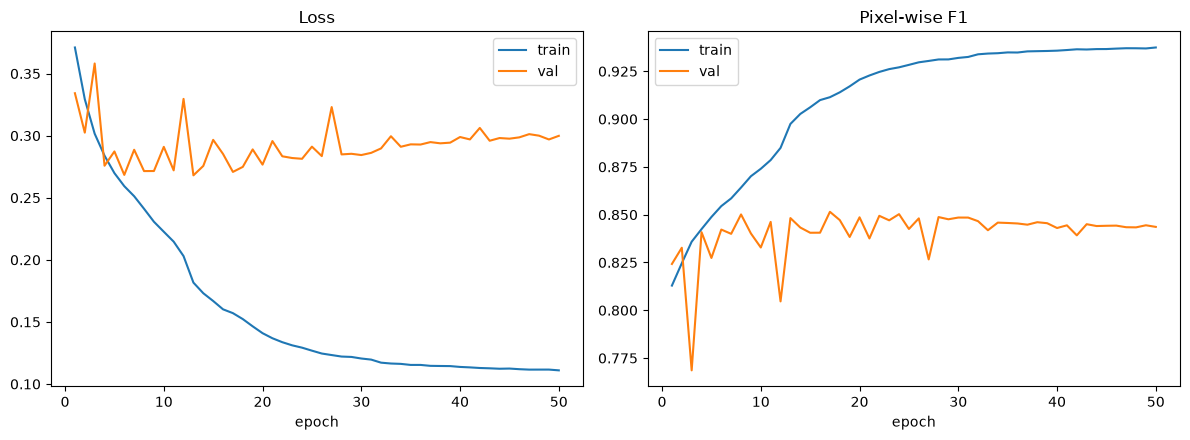

Saved training curves to D:\SolarMap-India\outputs\PSPNet\plots\training_curves.png


In [45]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

train_f1 = [m["f1"] for m in history["train_metrics"]]
val_f1 = [m["f1"] for m in history["val_metrics"]]
axes[1].plot(epochs_range, train_f1, label="train")
axes[1].plot(epochs_range, val_f1, label="val")
axes[1].set_title("Pixel-wise F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved training curves to {curve_path}")


## Final metrics: pixel + instance (mAP) for train / val / test

In [ ]:
if os.path.isfile(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from {best_model_path} (epoch {checkpoint['epoch']})")

split_loaders = {"train": (train_loader, train_ids), "val": (val_loader, val_ids), "test": (test_loader, test_ids)}
summary_rows = []

for split_name, (loader, ids) in split_loaders.items():
    loss, pixel_metrics = run_epoch(loader, model, optimizer=None)
    inst_metrics = evaluate_instances(
        model, ids, images_by_id, annotations_by_image, IMAGES_DIR, IMG_SIZE, DEVICE,
        iou_thresholds=IOU_THRESHOLDS, prob_threshold=PROB_THRESHOLD, min_area=MIN_INSTANCE_AREA,
    )

    row = {
        "split": split_name,
        "loss": loss,
        "pixel_accuracy": pixel_metrics["accuracy"],
        "pixel_precision": pixel_metrics["precision"],
        "pixel_recall": pixel_metrics["recall"],
        "pixel_f1": pixel_metrics["f1"],
        "pixel_dice": pixel_metrics["dice"],
        "pixel_iou": pixel_metrics["iou"],
        "instance_precision": inst_metrics.get("instance_precision", float("nan")),
        "instance_recall": inst_metrics.get("instance_recall", float("nan")),
        "instance_f1": inst_metrics.get("instance_f1", float("nan")),
        "map_50": inst_metrics.get("map_50", float("nan")),
        "map_95": inst_metrics.get("map_95", float("nan")),
        "num_gt_instances": inst_metrics["num_gt_instances"],
        "num_predicted_instances": inst_metrics["num_predicted_instances"],
    }
    summary_rows.append(row)

    print(f"\n===== {split_name.upper()} =====")
    print(f"loss={loss:.4f}")
    print(f"Pixel    -> acc={row['pixel_accuracy']:.4f} prec={row['pixel_precision']:.4f} "
          f"recall={row['pixel_recall']:.4f} f1={row['pixel_f1']:.4f}")
    print(f"Instance -> prec={row['instance_precision']:.4f} recall={row['instance_recall']:.4f} "
          f"f1={row['instance_f1']:.4f}")
    print(f"mAP@50={row['map_50']:.4f}  mAP@95={row['map_95']:.4f}")

summary_path = os.path.join(METRICS_DIR, "metrics_summary_train_val_test.csv")
fieldnames = list(summary_rows[0].keys())
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"\nSaved full train/val/test metric summary to {summary_path}")


Loaded best model from D:\SolarMap-India\outputs\PSPNet\models\pspnet_best.pth (epoch 13)


KeyboardInterrupt: 

## Save final model

In [47]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "unet_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to D:\SolarMap-India\outputs\PSPNet\models\unet_final.pth


## Sample prediction visualizations (saved to outputs/predictions)

In [48]:
def save_prediction_examples(model, image_ids, images_by_id, annotations_by_image, images_dir,
                              img_size, device, out_dir, num_examples=6):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    sample_ids = image_ids[:num_examples]
    with torch.no_grad():
        for image_id in sample_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])
            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)
            logits = model(image_t)
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

            gt_mask = semantic_mask_for_image(entry, anns)
            gt_mask = np.array(Image.fromarray(gt_mask * 255).resize((img_size, img_size), Image.NEAREST)) > 127

            input_disp = np.array(image.resize((img_size, img_size)))
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(input_disp); axes[0].set_title("Input"); axes[0].axis("off")
            axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction"); axes[2].axis("off")
            plt.tight_layout()
            out_path = os.path.join(out_dir, f"{entry['file_name'].rsplit('.', 1)[0]}_comparison.png")
            plt.savefig(out_path, dpi=130)
            plt.close(fig)

save_prediction_examples(model, test_ids, images_by_id, annotations_by_image, IMAGES_DIR,
                          IMG_SIZE, DEVICE, PREDICTIONS_DIR, num_examples=6)
print(f"Saved sample prediction comparisons to {PREDICTIONS_DIR}")


Saved sample prediction comparisons to D:\SolarMap-India\outputs\PSPNet\predictions


In [15]:
# ============================================================
# LOAD PSPNET BEST CHECKPOINT
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


model = PSPNet(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(device)

CHECKPOINT_PATH = r"D:\SolarMap-India\outputs\PSPNet\models\pspnet_best.pth"

print("Checkpoint:", CHECKPOINT_PATH)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Checkpoint loaded successfully.")
    print("Saved epoch:", checkpoint.get("epoch", "N/A"))
else:
    model.load_state_dict(checkpoint)
    print("Model weights loaded successfully.")

model.eval()

print("PSPNet is ready for testing.")

Device: cuda
GPU: NVIDIA GeForce RTX 2050
Checkpoint: D:\SolarMap-India\outputs\PSPNet\models\pspnet_best.pth
Checkpoint loaded successfully.
Saved epoch: 13
PSPNet is ready for testing.


In [25]:
# ============================================================
# PSPNET — TEST EVALUATION
# ============================================================

model.eval()

test_loss, test_metrics = run_epoch(
    test_loader,
    model,
    optimizer=None
)

print("\n" + "=" * 60)
print("PSPNET TEST RESULTS")
print("=" * 60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Accuracy       : {test_metrics['accuracy']:.4f}")
print(f"Precision      : {test_metrics['precision']:.4f}")
print(f"Recall         : {test_metrics['recall']:.4f}")
print(f"F1 / Dice      : {test_metrics['f1']:.4f}")
print(f"IoU            : {test_metrics['iou']:.4f}")
print(f"Dice Loss      : {test_metrics['dice_loss']:.4f}")


PSPNET TEST RESULTS
Test Loss      : 0.2622
Accuracy       : 0.9728
Precision      : 0.8768
Recall         : 0.8319
F1 / Dice      : 0.8515
IoU            : 0.7662
Dice Loss      : 0.1485
